# K-Means Clustering

K-Means Clustering splits data into a given k number of clusters. By minimizing the distance between points and their closest cluster centroid, we are able to iterate and optimize centroid placement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rice_ml.unsupervised_learning import KMeansClustering
from sklearn.preprocessing import StandardScaler


# Data Loading

The Mall Customers dataset from Kaggle has 200 samples and 5 features:
- CustomerID
- Gender
- Age
- Annual Income
- Spending Score

The data is loaded in a pandas dataframe.

In [2]:
input_file = 'Mall_Customers.csv'
columns = [
    'CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'
]
df = pd.read_csv(input_file, header=None, names=columns)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Data Preprocessing
CustomerID, Gender, and Age are dropped, and the data is standardised. This is unsupervised, so there is no label y.

In [3]:
X = df.drop(['CustomerID', 'Gender', 'Age'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K Selection - Elbow Method
Before we can train our full mode, we need to select the number of clusters. This will be based on when diminishing returns on inertia begins. Each k value is run multiple times to minimize the effects of bad random seeding.

C:\Users\hawkv\AppData\Local\Temp\ipykernel_30252\781488780.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


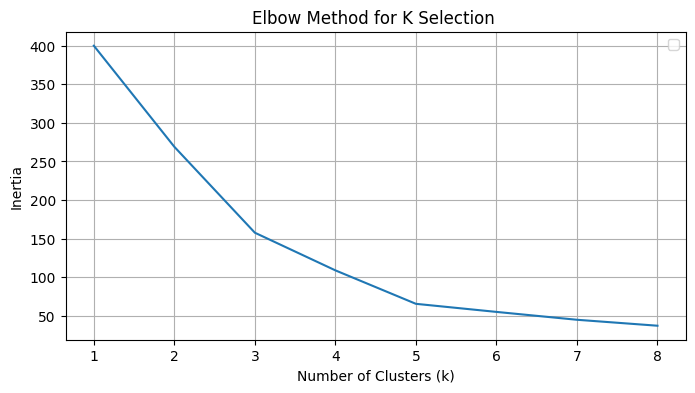

In [6]:
inertias = []
for k in range(1, 9):
    best = float('inf')
    for _ in range(20):
        model = KMeansClustering(k = k)
        model.train(X_scaled)
        best = min(best, model.inertia(X_scaled))
    inertias.append(best)

plt.figure(figsize=(8,4))
plt.plot(list(range(1, 9)), inertias)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Selection ")
plt.legend()
plt.grid(True)
plt.show()
     

# Applying Model
Based on the graph, we should use 3-5 clusters for this. Let's use k=5 and visualize the results.

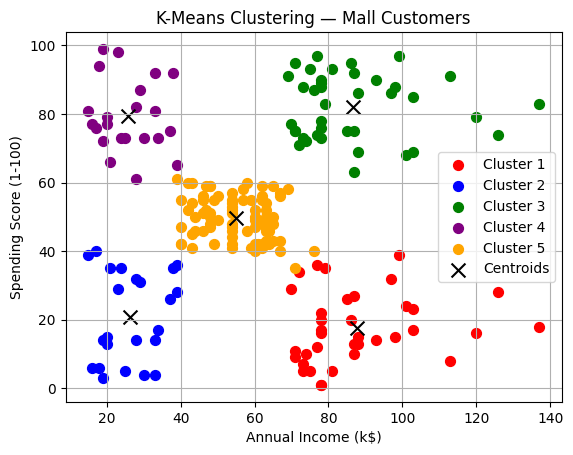

In [7]:
model = KMeansClustering(k=5, random_state=42)
model.train(X_scaled)
labels = model.predict(X_scaled)
centroids = model.centroids
plt.figure()
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    mask = labels == i
    X_original = scaler.inverse_transform(X_scaled)
    plt.scatter(X_original[mask, 0], X_original[mask, 1], color=colors[i], s=50, label=f'Cluster {i + 1}')

# Plot centroids in original scale
centroids_original = scaler.inverse_transform(centroids)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker = "x", s=100, label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering — Mall Customers")
plt.legend()
plt.grid(True)
plt.show()


# Interpretation
We can see that there are 5 clusters identified by the model. 
- Cluster 1: High Income, Low Spending
- Cluster 2: Low Income, Low Spending
- Cluster 3: High Income, High Spending
- Cluster 4: Low Income, High Spending
- Cluster 5: Middle Income, Middle Spending